In [49]:
# Starting with the usual imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# to make the plots look a bit nicer
sns.set(style="whitegrid")

In [50]:
# Loading the dataset, make sure the file path is correct
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

# Taking a quick look to understand what we're dealing with
df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [51]:
# Checking the structure: column types, non-null counts, etc.
df.info()

# Getting a statistical summary for numerical columns
df.describe()
df['ChurnLabel'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64

In [52]:
# see if we have any missing values hiding in the dataset
df.isnull().sum()

CustomerID                          0
Gender                              0
Age                                 0
Under30                             0
SeniorCitizen                       0
Married                             0
Dependents                          0
NumberofDependents                  0
Country                             0
State                               0
City                                0
ZipCode                             0
Latitude                            0
Longitude                           0
Population                          0
Quarter                             0
ReferredaFriend                     0
Number_of_Referrals                 0
TenureinMonths                      0
Offer                            3877
PhoneService                        0
AvgMonthlyLongDistanceCharges       0
MultipleLines                       0
InternetService                     0
InternetType                     1526
AvgMonthlyGBDownload                0
OnlineSecuri

In [54]:
# 'TotalCharges' sometimes gets read as object due to blank spaces
# Converting it to numeric, forcing errors to NaN so we can handle them
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [59]:
# Checking again after conversion
df.isnull().sum()

CustomerID                          0
Gender                              0
Age                                 0
Under30                             0
SeniorCitizen                       0
Married                             0
Dependents                          0
NumberofDependents                  0
Country                             0
State                               0
City                                0
ZipCode                             0
Latitude                            0
Longitude                           0
Population                          0
Quarter                             0
ReferredaFriend                     0
Number_of_Referrals                 0
TenureinMonths                      0
Offer                            3877
PhoneService                        0
AvgMonthlyLongDistanceCharges       0
MultipleLines                       0
InternetService                     0
InternetType                     1526
AvgMonthlyGBDownload                0
OnlineSecuri

In [60]:
df['ChurnLabel'].value_counts()

ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64

In [61]:
# Converting 'Churn' from Yes/No to 1/0 for easier analysis
df['ChurnLabel'] = df['ChurnLabel'].map({'Yes': 1, 'No': 0})
df['ChurnLabel'].value_counts()

ChurnLabel
0    5174
1    1869
Name: count, dtype: int64

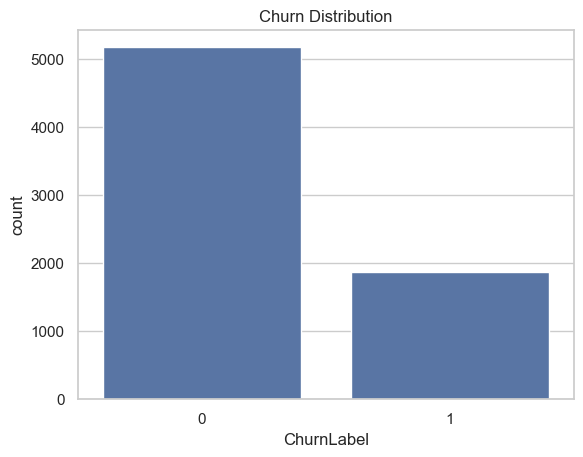

In [62]:
# Checking how balanced (or imbalanced) the target variable is
sns.countplot(x='ChurnLabel', data=df)
plt.title("Churn Distribution")

# From experience, churn datasets are usually imbalanced — let's confirm visually
plt.show()

In [64]:
# Okay, looks like we actually have quite a few missing values
# Let's check both count and percentage to understand the scale

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
ChurnReason,5174,73.463013
ChurnCategory,5174,73.463013
Offer,3877,55.047565
InternetType,1526,21.666903
SeniorCitizen,0,0.000000
Married,0,0.000000
Age,0,0.000000
Under30,0,0.000000
Country,0,0.000000
State,0,0.000000


In [65]:
# These columns directly describe churn AFTER it happens
# So they should NOT be used as features

df = df.drop(['ChurnReason', 'ChurnCategory'], axis=1)

In [66]:
# Replace missing with a meaningful label
df['Offer'] = df['Offer'].fillna('No Offer')

In [67]:
df['InternetType'] = df['InternetType'].fillna('No Internet')

In [68]:
df.isnull().sum()

CustomerID                       0
Gender                           0
Age                              0
Under30                          0
SeniorCitizen                    0
Married                          0
Dependents                       0
NumberofDependents               0
Country                          0
State                            0
City                             0
ZipCode                          0
Latitude                         0
Longitude                        0
Population                       0
Quarter                          0
ReferredaFriend                  0
Number_of_Referrals              0
TenureinMonths                   0
Offer                            0
PhoneService                     0
AvgMonthlyLongDistanceCharges    0
MultipleLines                    0
InternetService                  0
InternetType                     0
AvgMonthlyGBDownload             0
OnlineSecurity                   0
OnlineBackup                     0
DeviceProtectionPlan

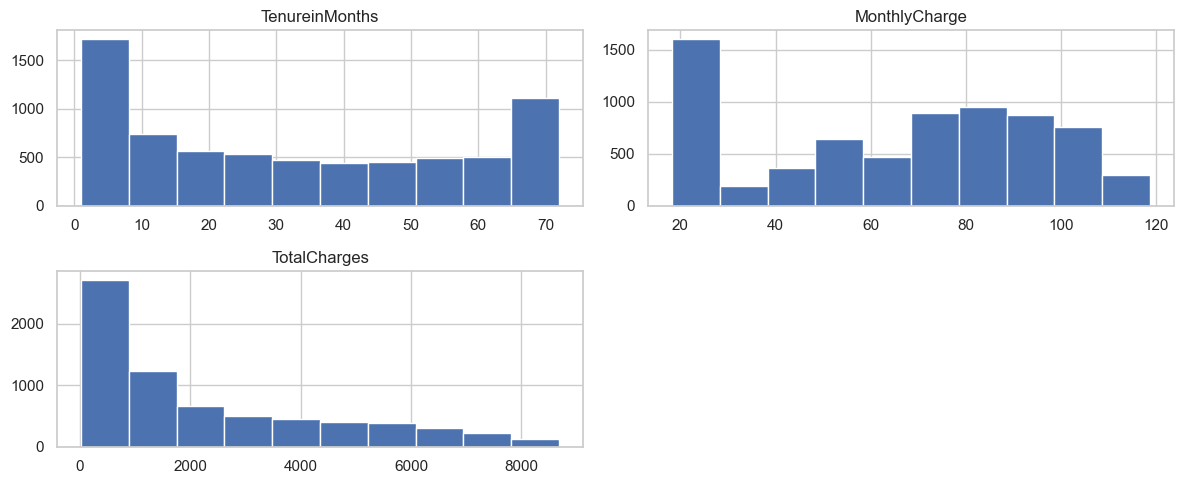

In [72]:
# Plotting histograms to understand distribution of key numeric features
df[['TenureinMonths', 'MonthlyCharge', 'TotalCharges']].hist(figsize=(12,5))

# This helps spot skewness and unusual values
plt.tight_layout()
plt.show()

In [73]:
# Printing value counts for categorical columns
# This gives a quick sense of how categories are distributed
for col in df.select_dtypes(include='object'):
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: CustomerID
CustomerID
3186-AJIEK    1
8779-QRDMV    1
7495-OOKFY    1
4807-IZYOZ    1
1471-GIQKQ    1
             ..
3445-HXXGF    1
0390-DCFDQ    1
4412-YLTKF    1
4846-WHAFZ    1
4598-XLKNJ    1
Name: count, Length: 7043, dtype: int64

Column: Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Under30
Under30
No     5642
Yes    1401
Name: count, dtype: int64

Column: SeniorCitizen
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

Column: Married
Married
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Column: Country
Country
United States    7043
Name: count, dtype: int64

Column: State
State
California    7043
Name: count, dtype: int64

Column: City
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Eldridge              2
South Lake Tahoe      2
Johann

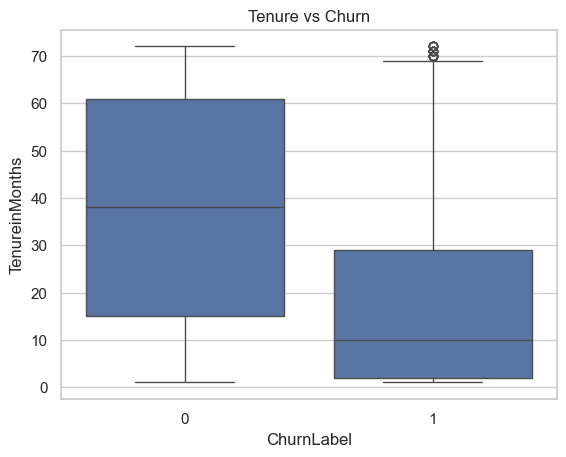

In [76]:
# Comparing tenure for churned vs non-churned customers
sns.boxplot(x='ChurnLabel', y='TenureinMonths', data=df)

# Expectation: customers who churn usually have lower tenure
plt.title("Tenure vs Churn")
plt.show()

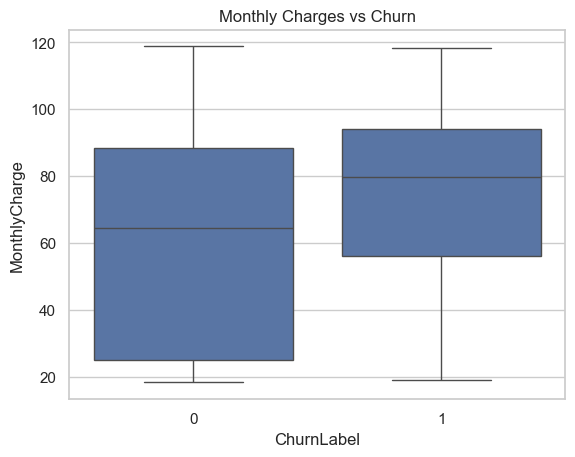

In [78]:
# Checking if higher monthly charges influence churn
sns.boxplot(x='ChurnLabel', y='MonthlyCharge', data=df)

# Often, higher-paying customers are more likely to churn
plt.title("Monthly Charges vs Churn")
plt.show()

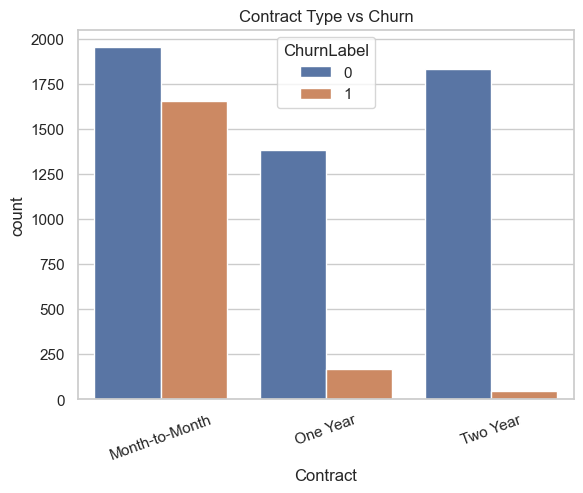

In [80]:
# Contract type is usually one of the strongest indicators of churn
sns.countplot(x='Contract', hue='ChurnLabel', data=df)

# Month-to-month users are typically more likely to leave
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

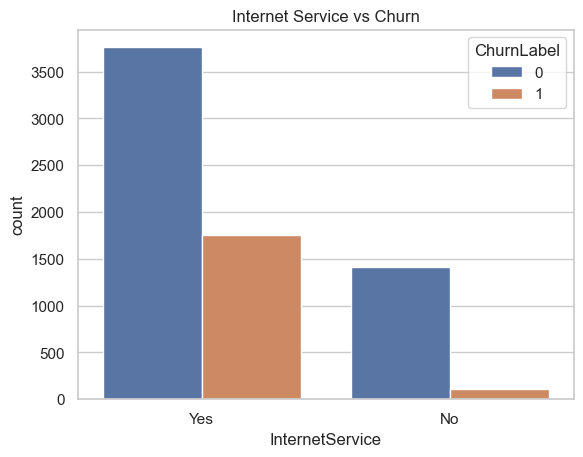

In [82]:
# Checking how different internet services relate to churn
sns.countplot(x='InternetService', hue='ChurnLabel', data=df)

# Fiber users often show higher churn in this dataset
plt.title("Internet Service vs Churn")
plt.show()

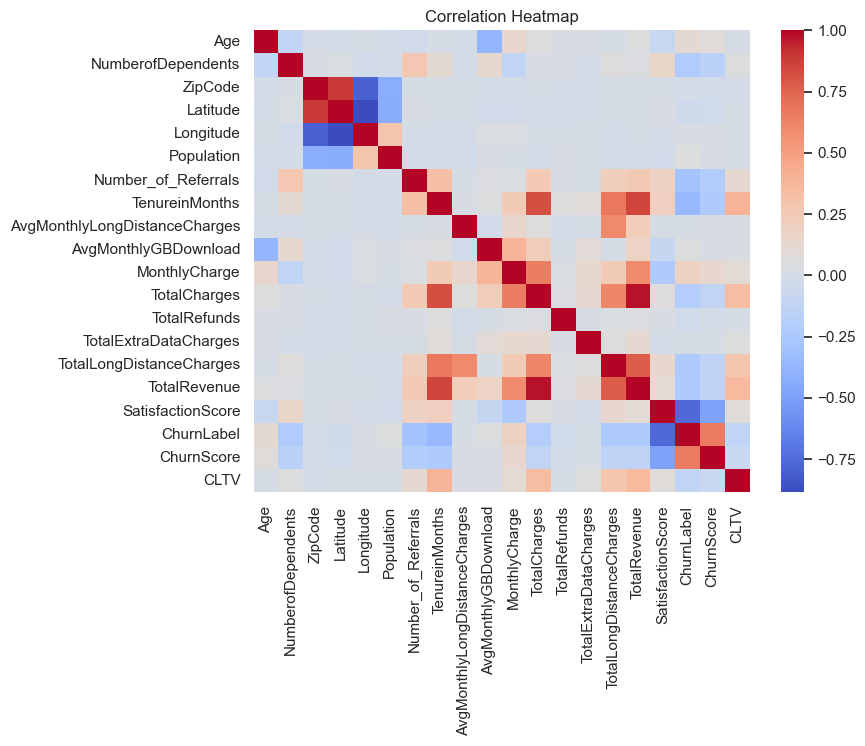

In [84]:
# Looking at correlations between numeric features
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm')

# Helps identify relationships and possible multicollinearity
plt.title("Correlation Heatmap")
plt.show()

In [85]:
# Grouping tenure into buckets to make patterns clearer
df['tenure_group'] = pd.cut(df['TenureinMonths'], bins=[0,12,24,48,60,72])

# This can help in visualization and modeling later
df['tenure_group'].value_counts()

tenure_group
(0, 12]     2186
(24, 48]    1594
(60, 72]    1407
(12, 24]    1024
(48, 60]     832
Name: count, dtype: int64

In [86]:
# Checking proportion of churn vs non-churn
df['ChurnLabel'].value_counts(normalize=True)

# If heavily imbalanced, we might need special handling later

ChurnLabel
0    0.73463
1    0.26537
Name: proportion, dtype: float64